In [1]:
# Install the Dependencies
!pip install pandas numpy scikit-learn imbalanced-learn shap matplotlib seaborn xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.4/235.4 kB 14.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 57.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.7/131.7 MB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 289.8/289.8 MB 1.2 MB/s eta 0:00:00


In [2]:
#Importing the required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.metrics import classification_report, confusion_matrix

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.decomposition import PCA

from imblearn.over_sampling import SMOTE

import shap
import pickle

In [3]:
#Loading the dataset
features = pd.read_csv("/content/elliptic_txs_features.csv", header=None)
classes = pd.read_csv("/content/elliptic_txs_classes.csv")

df = features.merge(classes, left_on=0, right_on="txId")

df.head()

,0,1,2,3,4,5,6,7,8,9,...,159,160,161,162,163,164,165,166,txId,class
0,230425980,1,-0.171469,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162097,...,1.461330,1.461369,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792,230425980,unknown
1,5530458,1,-0.171484,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162112,...,-0.979074,-0.978556,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792,5530458,unknown
2,232022460,1,-0.172107,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162749,...,-0.979074,-0.978556,-0.098889,-0.106715,-0.131155,-0.183671,-0.120613,-0.119792,232022460,unknown
3,232438397,1,0.163054,1.963790,-0.646376,12.409294,-0.063725,9.782742,12.414558,-0.163645,...,0.241128,0.241406,1.072793,0.085530,-0.131155,0.677799,-0.120613,-0.119792,232438397,2
4,230460314,1,1.011523,-0.081127,-1.201369,1.153668,0.333276,1.312656,-0.061584,-0.163523,...,0.517257,0.579382,0.018279,0.277775,0.326394,1.293750,0.178136,0.179117,230460314,unknown


Exploaratory Data Analysis


In [4]:
#Dataset Info
print("Shape:", df.shape)
print(df.info())
print(df.describe())

Shape: (203769, 169)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 203769 entries, 0 to 203768
Columns: 169 entries, 0 to class
dtypes: float64(165), int64(3), object(1)
memory usage: 262.7+ MB
None
                  0              1             2             3             4  \
count  2.037690e+05  203769.000000  2.037690e+05  2.037690e+05  2.037690e+05   
mean   1.711310e+08      23.843961  2.454849e-17 -7.531922e-18  2.231681e-17   
std    1.104655e+08      15.172170  1.000002e+00  1.000002e+00  1.000002e+00   
min    1.076000e+03       1.000000 -1.729826e-01 -2.105526e-01 -1.756361e+00   
25%    8.433452e+07       9.000000 -1.725317e-01 -1.803266e-01 -1.201369e+00   
50%    1.624375e+08      23.000000 -1.692045e-01 -1.328975e-01  4.636092e-01   
75%    2.454798e+08      38.000000 -1.318553e-01 -5.524241e-02  1.018602e+00   
max    4.032446e+08      49.000000  7.168197e+01  7.359505e+01  2.683580e+00   

                  5             6             7             8             9 

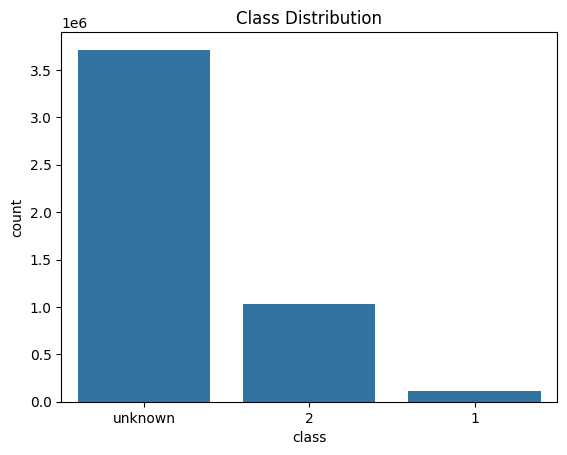

In [5]:
#Class Distribution
sns.countplot(x='class', data=df)
plt.title("Class Distribution")
plt.show()

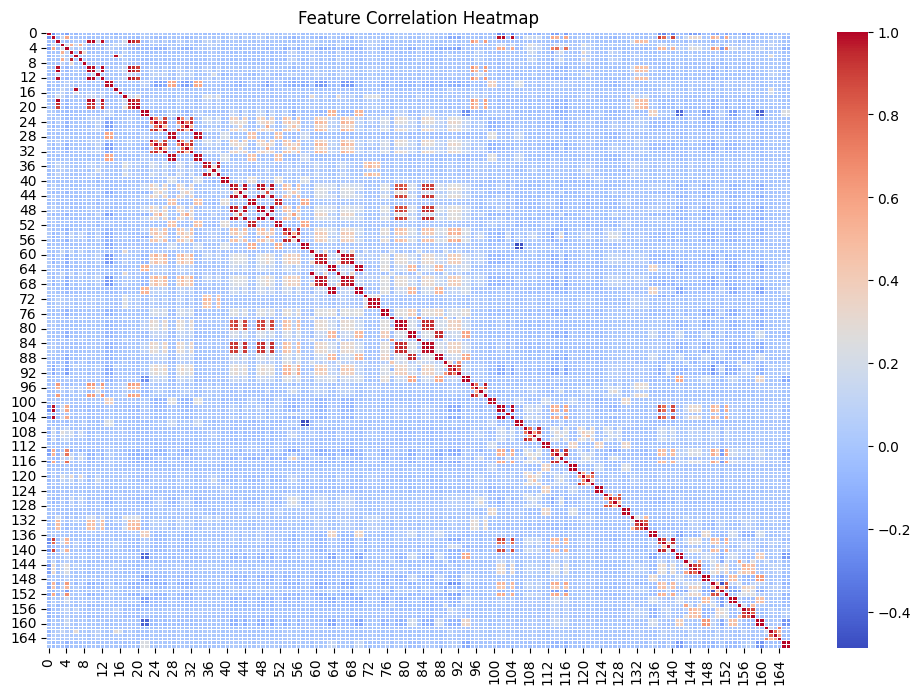

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#Loading the dataset
features = pd.read_csv("/content/elliptic_txs_features.csv", header=None)
classes = pd.read_csv("/content/elliptic_txs_classes.csv")

df = features.merge(classes, left_on=0, right_on="txId")

#Correaltion_Heatmap
plt.figure(figsize=(12,8))
corr = df.drop(columns=['txId', 'class']).corr()

sns.heatmap(corr, cmap='coolwarm', linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.show()

In [7]:
#Data Cleaning
df = df[df['class'] != 'unknown']
df['class'] = df['class'].map({'1': 1, '2': 0})
df.dropna(inplace=True)

df['class'].value_counts()

,count
class,
0,42019
1,4545


In [8]:
#Feature selection
X = df.drop(columns=['txId', 'class'])
y = df['class']

In [9]:
#SelectKBest
selector = SelectKBest(score_func=f_classif, k=20)
X_new = selector.fit_transform(X, y)

selected_features = X.columns[selector.get_support()]
print("Selected Features:", selected_features)

Selected Features: Index([ 53,  54,  55,  56,  60,  66,  78,  80,  84,  85,  86,  90,  91,  92,
       115, 143, 149, 151, 155, 157],
      dtype='object')


In [10]:
#PCA - Dimensionality Reduction
pca = PCA(n_components=20)
X_pca = pca.fit_transform(X_new)

In [11]:
#Test_Train_Split
X_train, X_test, y_train, y_test = train_test_split(
    X_pca, y, test_size=0.2, random_state=42, stratify=y
)

In [12]:
#Handle Imbalance
sm = SMOTE(random_state=42)
X_train, y_train = sm.fit_resample(X_train, y_train)

print("After SMOTE:", np.bincount(y_train))

After SMOTE: [33615 33615]


In [13]:
# Machine_Learning_Model_Selection
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(),
    "XGBoost": XGBClassifier(eval_metric='logloss')
}

In [14]:
#Hyperparameter Tuning
params = {
    "Logistic Regression": {
        "model__C": [0.1, 1, 10]
    },
    "Random Forest": {
        "model__n_estimators": [100],
        "model__max_depth": [10, 20]
    },
    "XGBoost": {
        "model__n_estimators": [100],
        "model__max_depth": [3, 6]
    }
}

In [15]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

import pandas as pd

# Store results
results = []

best_model = None
best_score = 0
best_name = ""

for name in models:
    print(f"\n Training {name}...")

    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("model", models[name])
    ])

    grid = GridSearchCV(
        pipeline,
        params[name],
        cv=3,
        scoring="f1",
        n_jobs=-1
    )

    grid.fit(X_train, y_train)

    # Predictions
    y_pred = grid.best_estimator_.predict(X_test)
    y_prob = grid.best_estimator_.predict_proba(X_test)[:, 1]

    # Metrics
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)
    pr_auc = average_precision_score(y_test, y_prob)

    print(f"Best CV F1 Score : {grid.best_score_:.4f}")
    print(f"Test F1 Score    : {f1:.4f}")

    # Store results
    results.append({
        "Model": name,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC-AUC": roc_auc,
        "PR-AUC": pr_auc
    })

    # Select best model based on F1 (test performance)
    if f1 > best_score:
        best_score = f1
        best_model = grid.best_estimator_
        best_name = name

# Convert results to DataFrame
results_df = pd.DataFrame(results)

print("\n Model Comparison:")
print(results_df.sort_values(by="F1 Score", ascending=False))

print("\n🏆 Best Model Selected:", best_name)
print(f"Best F1 Score: {best_score:.4f}")


 Training Logistic Regression...
Best CV F1 Score : 0.8435
Test F1 Score    : 0.4549

 Training Random Forest...
Best CV F1 Score : 0.9745
Test F1 Score    : 0.8264

 Training XGBoost...
Best CV F1 Score : 0.9656
Test F1 Score    : 0.7801

 Model Comparison:
                 Model  Precision    Recall  F1 Score   ROC-AUC    PR-AUC
1        Random Forest   0.794118  0.861386  0.826385  0.978161  0.919554
2              XGBoost   0.700525  0.880088  0.780107  0.977004  0.916805
0  Logistic Regression   0.304869  0.895490  0.454876  0.932478  0.585555

🏆 Best Model Selected: Random Forest
Best F1 Score: 0.8264


In [16]:
#EValuation
y_pred = best_model.predict(X_test)

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Confusion Matrix:
 [[8201  203]
 [ 126  783]]

Classification Report:

              precision    recall  f1-score   support

           0       0.98      0.98      0.98      8404
           1       0.79      0.86      0.83       909

    accuracy                           0.96      9313
   macro avg       0.89      0.92      0.90      9313
weighted avg       0.97      0.96      0.97      9313



In [21]:
#Imports for Threshold Tuning
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve,
    confusion_matrix
)

import numpy as np
import matplotlib.pyplot as plt

In [22]:
# Predicted probabilities
y_prob = best_model.predict_proba(X_test)[:, 1]

In [24]:
#Threshold Tuning
thresholds = np.arange(0.1, 0.9, 0.05)

results = []

for t in thresholds:
    y_pred_t = (y_prob >= t).astype(int)

    precision = precision_score(y_test, y_pred_t)
    recall = recall_score(y_test, y_pred_t)
    f1 = f1_score(y_test, y_pred_t)

    results.append({
        "Threshold": t,
        "Precision": precision,
        "Recall": recall,
        "F1": f1
    })

import pandas as pd
threshold_df = pd.DataFrame(results)

print(" Threshold Tuning Results:")
print(threshold_df)

 Threshold Tuning Results:
    Threshold  Precision    Recall        F1
0        0.10   0.362019  0.962596  0.526158
1        0.15   0.442208  0.942794  0.602037
2        0.20   0.514268  0.931793  0.662754
3        0.25   0.572988  0.924092  0.707368
4        0.30   0.631418  0.906491  0.744354
5        0.35   0.671667  0.886689  0.764343
6        0.40   0.717117  0.875688  0.788509
7        0.45   0.759082  0.873487  0.812276
8        0.50   0.794118  0.861386  0.826385
9        0.55   0.833333  0.852585  0.842849
10       0.60   0.858744  0.842684  0.850639
11       0.65   0.882009  0.830583  0.855524
12       0.70   0.903776  0.816282  0.857803
13       0.75   0.932484  0.805281  0.864227
14       0.80   0.943272  0.786579  0.857828
15       0.85   0.958735  0.766777  0.852078


In [25]:
#Select the best threshold
best_row = threshold_df.loc[threshold_df["F1"].idxmax()]

best_threshold = best_row["Threshold"]

print(f"\n Best Threshold: {best_threshold}")
print(best_row)


 Best Threshold: 0.7500000000000002
Threshold    0.750000
Precision    0.932484
Recall       0.805281
F1           0.864227
Name: 13, dtype: float64


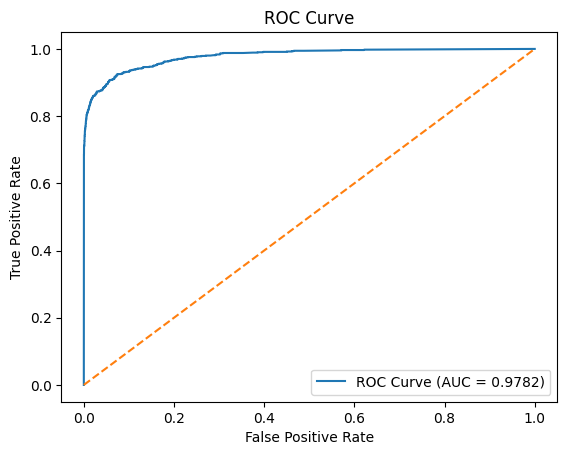

In [26]:
#ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = roc_auc_score(y_test, y_prob)

plt.figure()
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.4f})")
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

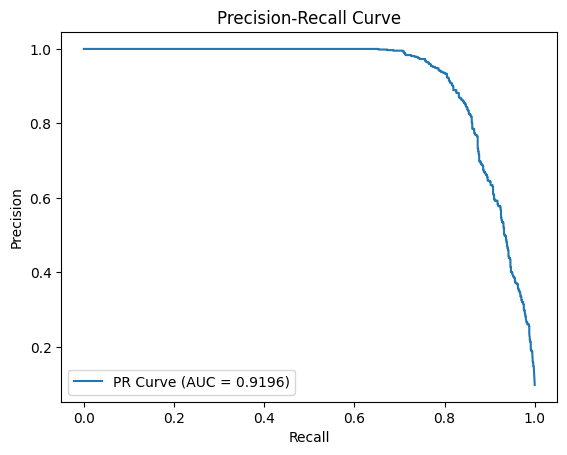

In [27]:
#Precision Recall Curve
precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_prob)
pr_auc = average_precision_score(y_test, y_prob)

plt.figure()
plt.plot(recall_vals, precision_vals, label=f"PR Curve (AUC = {pr_auc:.4f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()

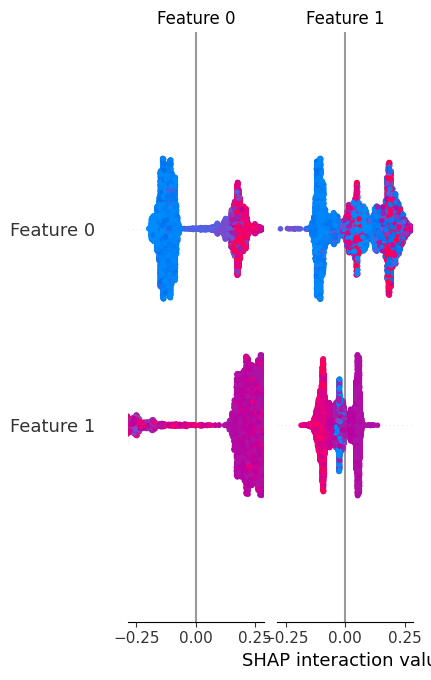

In [17]:
#SHAP Explainabilty
explainer = shap.Explainer(best_model.named_steps["model"])
shap_values = explainer(X_test)

shap.summary_plot(shap_values, X_test)

In [18]:
#Model Saving
with open("best_model.pkl", "wb") as f:
    pickle.dump(best_model, f)

print("Model saved!")

Model saved!


In [19]:
#Prediction Function
def predict(sample):
    sample = np.array(sample).reshape(1, -1)
    pred = best_model.predict(sample)

    return "Fraud" if pred[0] == 1 else "Legitimate"

In [20]:
#Test_Prediction
sample = X_test[0]
print(predict(sample))

Legitimate
